<a href="https://colab.research.google.com/github/ShrutiPatel263/AeroCare/blob/main/Basic_Models_FD004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Pre Processing

In [ ]:
import numpy as np
import pandas as pd

from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

# configure plotly graph objects
pio.renderers.default = 'iframe'
# pio.renderers.default = 'vscode'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
#     layout_hovermode = 'closest',
#     layout_hoverdistance = -1,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
#     plot_bgcolor="white",
)

# pio.templates.default = 'seaborn+ck_template+gridon'
pio.templates.default = 'ck_template+gridon'
# pio.templates.default = 'seaborn+gridon'
# pio.templates

In [ ]:
index_names = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
col_names = index_names + setting_names + sensor_names

In [ ]:
df_train = pd.read_csv('drive/MyDrive/archive/CMaps/train_FD004.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv('drive/MyDrive/archive/CMaps/test_FD004.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test_RUL = pd.read_csv('drive/MyDrive/archive/CMaps/RUL_FD004.txt',sep=r'\s+',header=None,index_col=False,names=['RUL'])

In [ ]:
df_train.head()


,engine,cycle,setting_1,setting_2,setting_3,(Fan inlet temperature) (◦R),(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(Fan inlet Pressure) (psia),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(Engine pressure ratio(P50/P2),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Burner fuel-air ratio),(Bleed Enthalpy),(Required fan speed),(Required fan conversion speed),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow)
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   engine                                   61249 non-null  int64  
 1   cycle                                    61249 non-null  int64  
 2   setting_1                                61249 non-null  float64
 3   setting_2                                61249 non-null  float64
 4   setting_3                                61249 non-null  float64
 5   (Fan inlet temperature) (◦R)             61249 non-null  float64
 6   (LPC outlet temperature) (◦R)            61249 non-null  float64
 7   (HPC outlet temperature) (◦R)            61249 non-null  float64
 8   (LPT outlet temperature) (◦R)            61249 non-null  float64
 9   (Fan inlet Pressure) (psia)              61249 non-null  float64
 10  (bypass-duct pressure) (psia)            61249

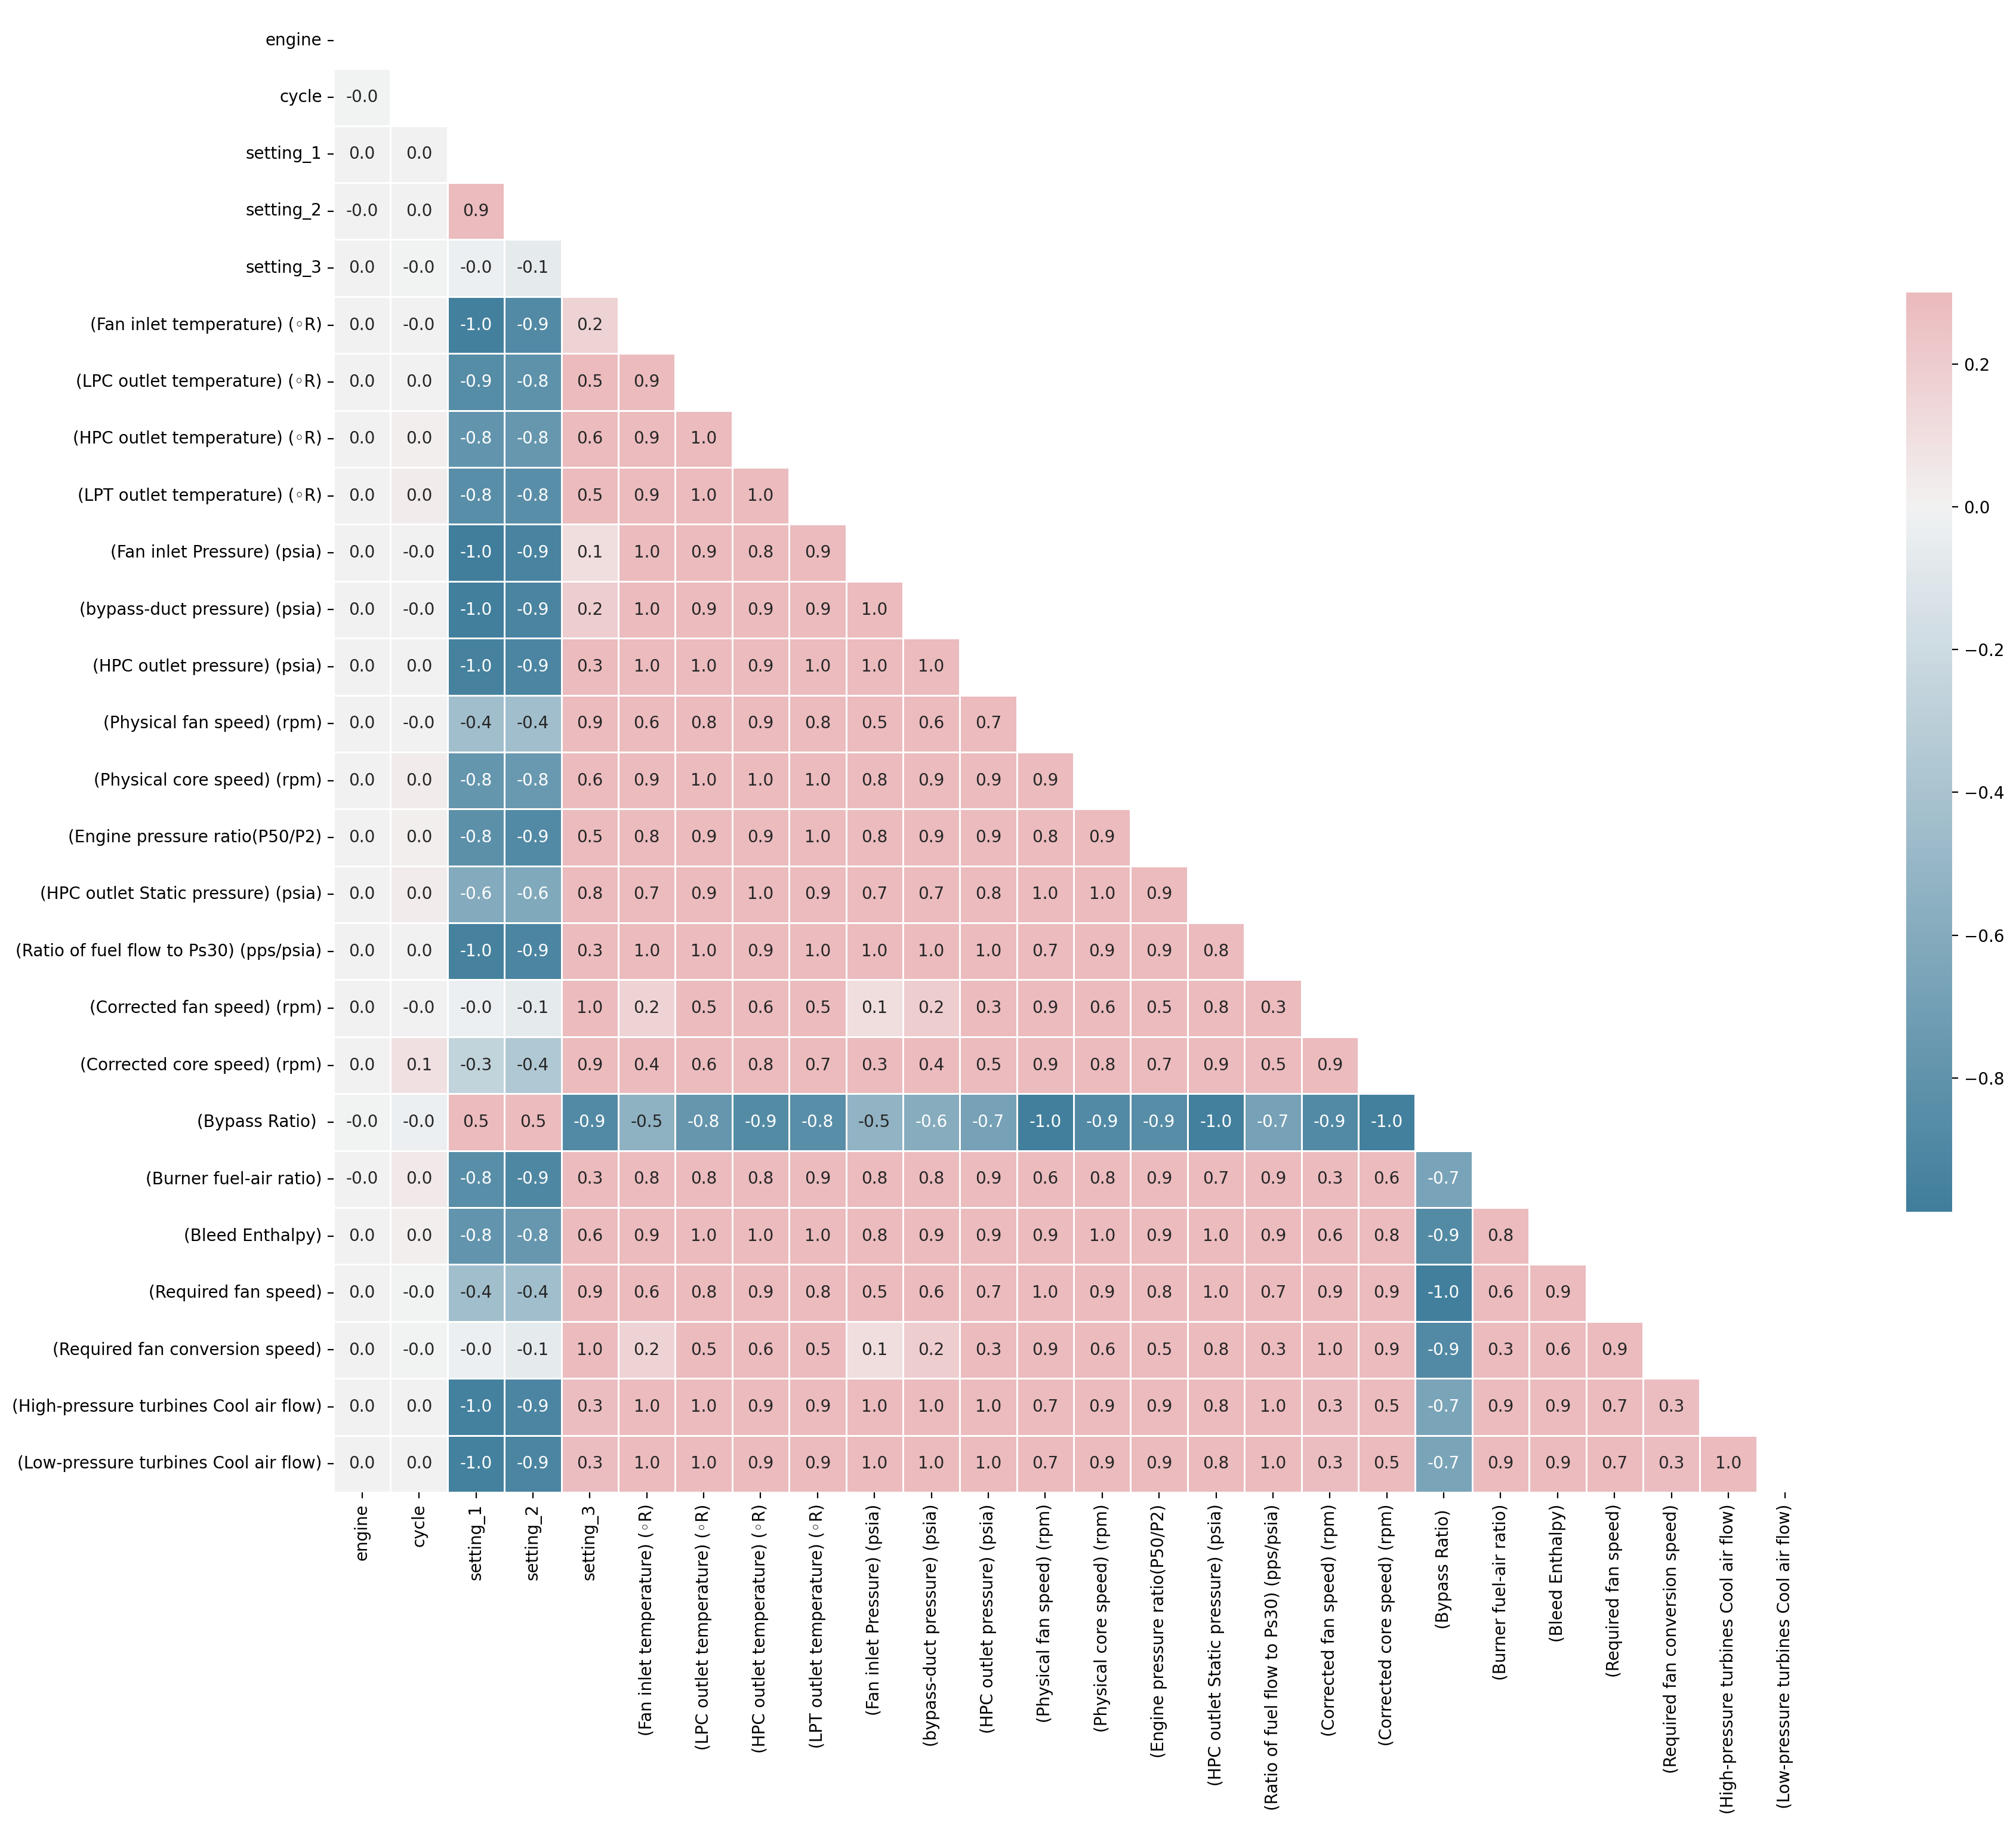

In [ ]:

corr = df_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with annotation
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=True,           # <- Add this line
    fmt=".1f"             # <- Format the numbers to 2 decimal places
)

plt.show()


In [ ]:
sens_const_values = []
for feature in list(setting_names + sensor_names):
    try:
        if df_train[feature].min()==df_train[feature].max():
            sens_const_values.append(feature)
    except:
        pass

print(sens_const_values)
df_train.drop(sens_const_values,axis=1,inplace=True)
df_test.drop(sens_const_values,axis=1,inplace=True)

[]


In [ ]:
cor_matrix = df_train.corr().abs()
upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),k=1).astype(np.bool))
corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(corr_features)
df_train.drop(corr_features,axis=1,inplace=True)
df_test.drop(corr_features,axis=1,inplace=True)

['(Fan inlet temperature) (◦R)', '(HPC outlet temperature) (◦R)', '(LPT outlet temperature) (◦R)', '(Fan inlet Pressure) (psia)', '(bypass-duct pressure) (psia)', '(HPC outlet pressure) (psia)', '(Physical core speed) (rpm)', '(Engine pressure ratio(P50/P2)', '(HPC outlet Static pressure) (psia)', '(Ratio of fuel flow to Ps30) (pps/psia)', '(Corrected fan speed) (rpm)', '(Bypass Ratio) ', '(Bleed Enthalpy)', '(Required fan speed)', '(Required fan conversion speed)', '(High-pressure turbines Cool air flow)', '(Low-pressure turbines Cool air flow)']


In [ ]:
list(df_train)

['engine',
 'cycle',
 'setting_1',
 'setting_2',
 'setting_3',
 '(LPC outlet temperature) (◦R)',
 '(Physical fan speed) (rpm)',
 '(Corrected core speed) (rpm)',
 '(Burner fuel-air ratio)']

In [ ]:
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,(LPC outlet temperature) (◦R),(Physical fan speed) (rpm),(Corrected core speed) (rpm),(Burner fuel-air ratio)
0,1,1,42.0049,0.8400,100.0,549.68,2211.86,8074.83,0.02
1,1,2,20.0020,0.7002,100.0,606.07,2323.66,8046.13,0.02
2,1,3,42.0038,0.8409,100.0,548.95,2211.92,8066.62,0.02
3,1,4,42.0000,0.8400,100.0,548.70,2211.88,8076.05,0.02
4,1,5,25.0063,0.6207,60.0,536.10,1915.22,7865.80,0.02


In [ ]:
features = list(df_train.columns)

In [ ]:
# check for missing data
for feature in features:
    print(feature + " - " + str(len(df_train[df_train[feature].isna()])))

engine - 0
cycle - 0
setting_1 - 0
setting_2 - 0
setting_3 - 0
(LPC outlet temperature) (◦R) - 0
(Physical fan speed) (rpm) - 0
(Corrected core speed) (rpm) - 0
(Burner fuel-air ratio) - 0


In [ ]:
# define the maximum life of each engine, as this could be used to obtain the RUL at each point in time of the engine's life
df_train_RUL = df_train.groupby(['engine']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train_RUL.head()

,life
engine,
1,321
2,299
3,307
4,274
5,193


In [ ]:
df_train=df_train.merge(df_train_RUL,how='left',on=['engine'])

In [ ]:
df_train['RUL']=df_train['life']-df_train['cycle']
df_train.drop(['life'],axis=1,inplace=True)

# the RUL prediction is only useful nearer to the end of the engine's life, therefore we put an upper limit on the RUL
# this is a bit sneaky, since it supposes that the test set has RULs of less than this value, the closer you are
# to the true value, the more accurate the model will be
df_train['RUL'][df_train['RUL']>125]=125
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,(LPC outlet temperature) (◦R),(Physical fan speed) (rpm),(Corrected core speed) (rpm),(Burner fuel-air ratio),RUL
0,1,1,42.0049,0.8400,100.0,549.68,2211.86,8074.83,0.02,125
1,1,2,20.0020,0.7002,100.0,606.07,2323.66,8046.13,0.02,125
2,1,3,42.0038,0.8409,100.0,548.95,2211.92,8066.62,0.02,125
3,1,4,42.0000,0.8400,100.0,548.70,2211.88,8076.05,0.02,125
4,1,5,25.0063,0.6207,60.0,536.10,1915.22,7865.80,0.02,125


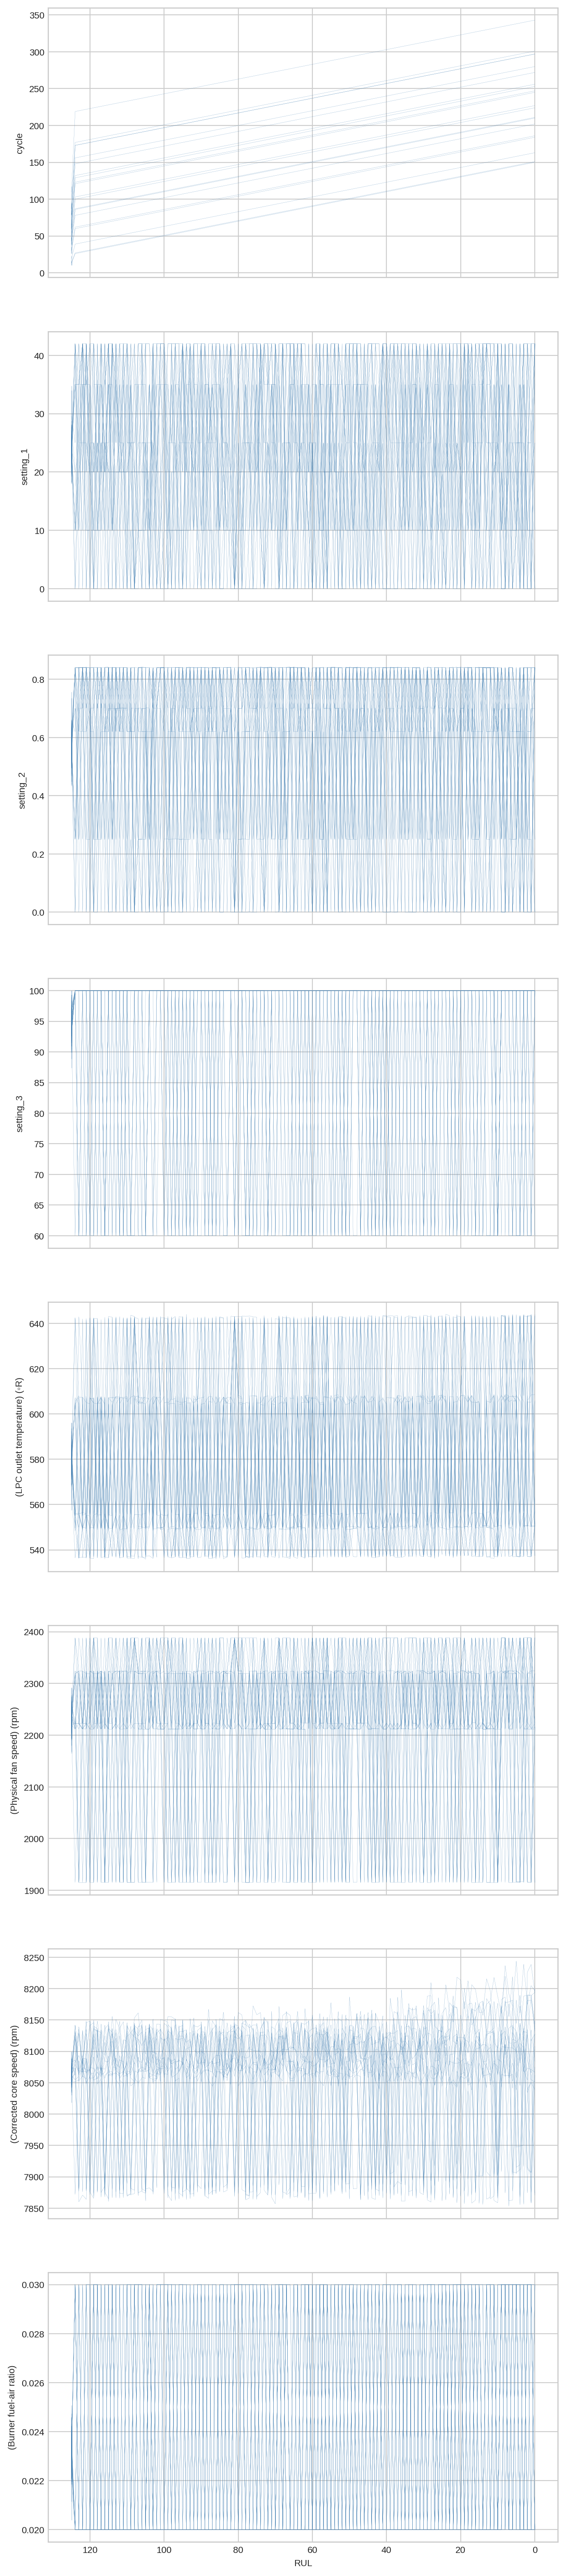

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=8,40
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 8
plt.rcParams['lines.linewidth'] = 0.1
plot_items = list(df_train.columns)[1:-1]
fig,ax = plt.subplots(len(plot_items),sharex=True)
ax[0].invert_xaxis()

engines = list(df_train['engine'].unique())

for engine in engines[10:30]:
    for i,item in enumerate(plot_items):
        f = sns.lineplot(data=df_train[df_train['engine']==engine],x='RUL',y=item,color='steelblue',ax=ax[i],
                        )

In [ ]:


Selected_Features = []
import statsmodels.api as sm

def backward_regression(X, y, initial_list=[], threshold_out=0.05, verbose=True):
    """To select feature with Backward Stepwise Regression

    Args:
        X -- features values
        y -- target variable
        initial_list -- features header
        threshold_out -- pvalue threshold of features to drop
        verbose -- true to produce lots of logging output

    Returns:
        list of selected features for modeling
    """
    included = list(X.columns)
    while True:
        changed = False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()  # null if pvalues is empty
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f"worst_feature : {worst_feature}, {worst_pval} ")
        if not changed:
            break
    Selected_Features.append(included)
    print(f"\nSelected Features:\n{Selected_Features[0]}")


# Application of the backward regression function on our training data
X = df_train.iloc[:,1:-1]
y = df_train.iloc[:,-1]
backward_regression(X, y)


Selected Features:
['cycle', 'setting_1', 'setting_2', 'setting_3', '(LPC outlet temperature) (◦R)', '(Physical fan speed) (rpm)', '(Corrected core speed) (rpm)', '(Burner fuel-air ratio)']


In [ ]:
Selected_Features

[['cycle',
  'setting_1',
  'setting_2',
  'setting_3',
  '(LPC outlet temperature) (◦R)',
  '(Physical fan speed) (rpm)',
  '(Corrected core speed) (rpm)',
  '(Burner fuel-air ratio)']]

In [ ]:
# X.head()
feature_names = Selected_Features[0]
np.shape(X)

(61249, 8)

In [ ]:
import time
model_performance = pd.DataFrame(columns=['r-Squared','RMSE','total time'])

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer, accuracy_score

import sklearn
from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.ensemble import RandomForestRegressor

model_performance = pd.DataFrame(columns=['R2','RMSE', 'time to train','time to predict','total time'])


def R_squared(y_true, y_pred):
    SS_res =  K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res/(SS_tot + K.epsilon())

In [ ]:
df_test_cycle = df_test.groupby(['engine']).agg({'cycle':'max'})
df_test_cycle.rename(columns={'cycle':'life'},inplace=True)
df_test_max = df_test.merge(df_test_cycle,how='left',on=['engine'])
df_test_max = df_test_max[(df_test_max['cycle']==df_test_max['life'])]
df_test_max.drop(['life'],axis=1,inplace=True)
# df_test_max

In [ ]:
X_train = df_train[feature_names]
y_train = df_train.iloc[:,-1]
X_test = df_test_max[feature_names]
y_test = df_test_RUL.iloc[:,-1]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Knn

In [ ]:
# %%time
# from sklearn.neighbors import KNeighborsRegressor
# start = time.time()
# model = KNeighborsRegressor(n_neighbors=9).fit(X_train,y_train)
# end_train = time.time()
# y_predictions = model.predict(X_test) # These are the predictions from the test data.
# end_predict = time.time()



# model_performance.loc['kNN'] = [model.score(X_test,y_test),
#                                    # Remove squared=False and use np.sqrt()
#                                    np.sqrt(mean_squared_error(y_test,y_predictions)),
#                                    end_train-start,
#                                    end_predict-end_train,
#                                    end_predict-start]

# # Use model.score for R-squared
# print('R-squared error: '+ "{:.2%}".format(model.score(X_test,y_test)))
# # Use np.sqrt() for RMSE
# print('Root Mean Squared Error: '+ "{:.2f}".format(np.sqrt(mean_squared_error(y_test,y_predictions))))

In [ ]:
# %%time
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# import numpy as np

# start = time.time()

# # Define parameter distributions for random search
# param_distributions = {
#     'n_neighbors': randint(1, 31),              # Random integers between 1 and 30
#     'weights': ['uniform', 'distance'],         # Weight function
#     'p': [1, 2],                                # 1 = Manhattan, 2 = Euclidean
#     'leaf_size': randint(20, 50),               # Leaf size for tree algorithms
#     'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']  # Algorithm to compute neighbors
# }

# # Create base model
# knn = KNeighborsRegressor()

# # RandomizedSearchCV - faster than GridSearchCV
# random_search = RandomizedSearchCV(
#     knn,
#     param_distributions=param_distributions,
#     n_iter=20,              # Number of parameter settings sampled
#     cv=3,                   # 3-fold cross-validation (fast)
#     scoring='r2',           # Optimize for R-squared
#     n_jobs=-1,              # Use all CPU cores
#     random_state=42,
#     verbose=1
# )

# # Fit the random search
# random_search.fit(X_train, y_train)

# # Best model
# model = random_search.best_estimator_
# print(f"\nBest parameters: {random_search.best_params_}")
# print(f"Best CV score: {random_search.best_score_:.4f}")

# end_train = time.time()

# # Predictions
# y_predictions = model.predict(X_test)
# end_predict = time.time()

# # Store performance
# model_performance.loc['kNN'] = [
#     model.score(X_test, y_test),
#     np.sqrt(mean_squared_error(y_test, y_predictions)),
#     end_train - start,
#     end_predict - end_train,
#     end_predict - start
# ]

# # Use model.score for R-squared
# print('\nR-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)))
# # Use np.sqrt() for RMSE
# print('Root Mean Squared Error: ' + "{:.2f}".format(np.sqrt(mean_squared_error(y_test, y_predictions))))

In [ ]:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize']=5,5
# # Changed font.family to a font available in matplotlib to avoid warnings
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['lines.linewidth'] = 3
# plt.rcParams['axes.labelsize']=20
# plt.rcParams['xtick.labelsize']=16
# plt.rcParams['ytick.labelsize']=16
# plt.rcParams['legend.fontsize']=16

# fig,ax = plt.subplots()
# plt.title('Actual vs Predicted')
# plt.xlabel('Actual')
# plt.ylabel('Predicted')
# # Use the generated y_predictions for the scatter plot
# g = sns.scatterplot(x=y_test.values.flatten(),
#                     y=y_predictions,
#                     s=100,
#                     alpha=0.6,
#                     linewidth=1,
#                     edgecolor='black',
#                     ax=ax)
# # Use the generated y_predictions for the line plot
# f = sns.lineplot(x=[min(y_test.values.flatten()),max(y_test.values.flatten())],
#                  y=[min(y_test.values.flatten()),max(y_test.values.flatten())],
#                  linewidth=4,
#                  color='gray',
#                  ax=ax)

# # Calculate RMSE by taking the square root of the mean squared error
# rmse = mean_squared_error(y_test,y_predictions)**0.5

# # Calculate R-squared using the trained model
# r2 = model.score(X_test, y_test)

# x_pos = 0.05 * max(y_test)
# y_pos = 0.9 * max(y_predictions)

# plt.annotate(
#     text=(
#         # Use the calculated R-squared
#         'R-squared error: ' + "{:.2%}".format(r2) + '\n' +
#         'Root Mean Squared Error: ' + "{:.2f}".format(rmse)
#     ),
#     xy=(x_pos, y_pos),
#     size='medium',
#     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # optional for readability
# )

# xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
# g.set_xticklabels(xlabels)
# ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
# g.set_yticklabels(ylabels)
# sns.despine()

In [ ]:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize']=20,5

# fig,ax = plt.subplots()
# plt.ylabel('RUL')
# plt.xlabel('Engine nr')

# g = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
#                 y=y_test.values.flatten(),
#                 color='gray',
#                 label = 'actual',
#                 ax=ax)

# f = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
#                 y=y_predictions,
#                 color='steelblue',
#                 label = 'predictions',
#                 ax=ax)
# ax.legend()

# SVR

In [ ]:
%%time
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform
import numpy as np

start = time.time()

# Define parameter distributions for random search
param_distributions = {
    'C': loguniform(1, 1000),           # Log-uniform between 1 and 1000
    'gamma': loguniform(0.001, 1),      # Log-uniform between 0.001 and 1
    'epsilon': uniform(0.001, 0.1)      # Uniform between 0.001 and 0.101
}

# Create base model
svr = SVR(kernel="rbf")

# RandomizedSearchCV - faster than GridSearchCV
random_search = RandomizedSearchCV(
    svr,
    param_distributions=param_distributions,
    n_iter=20,              # Number of parameter settings sampled
    cv=3,                   # 3-fold cross-validation (fast)
    scoring='r2',           # Optimize for R-squared
    n_jobs=-1,              # Use all CPU cores
    random_state=42,
    verbose=1
)

# Fit the random search
random_search.fit(X_train, y_train)

# Best model
model = random_search.best_estimator_
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV score: {random_search.best_score_:.4f}")

end_train = time.time()

# Predictions
y_predictions = model.predict(X_test)
end_predict = time.time()

# Store performance
model_performance.loc['SVM'] = [
    model.score(X_test, y_test),
    np.sqrt(mean_squared_error(y_test, y_predictions)),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('\nR-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)))
print('Root Mean Squared Error: ' + "{:.2f}".format(np.sqrt(mean_squared_error(y_test, y_predictions))))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize']=5,5

# fig,ax = plt.subplots()
# plt.title('Actual vs Predicted')
# plt.xlabel('Actual')
# plt.ylabel('Predicted')
# g = sns.scatterplot(x=y_test,
#                 y=y_predictions,
#                 s=100,
#                 alpha=0.6,
#                 linewidth=1,
#                 edgecolor='black',
#                 ax=ax)
# f = sns.lineplot(x=[min(y_test),max(y_test)],
#              y=[min(y_test),max(y_test)],
#              linewidth=4,
#              color='gray',
#              ax=ax)

# # Calculate RMSE by taking the square root of the mean squared error
# rmse = mean_squared_error(y_test,y_predictions)**0.5

# # Calculate R-squared using the trained model
# r2 = model.score(X_test, y_test)

# x_pos = 0.05 * max(y_test)
# y_pos = 0.9 * max(y_predictions)

# plt.annotate(
#     text=(
#         'R-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)) + '\n' +
#         'Root Mean Squared Error: ' + "{:.2f}".format(rmse)
#     ),
#     xy=(x_pos, y_pos),
#     size='medium',
#     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # optional for readability
# )

# xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
# g.set_xticklabels(xlabels)
# ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
# g.set_yticklabels(ylabels)
# sns.despine()

In [ ]:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize']=20,5

# fig,ax = plt.subplots()
# plt.ylabel('RUL')
# plt.xlabel('Engine nr')

# g = sns.lineplot(x = np.arange(0,len(df_train['engine'].unique())),
#                 y=y_test,
#                 color='gray',
#                 label = 'actual',
#                 ax=ax)

# f = sns.lineplot(x = np.arange(0,len(df_train['engine'].unique())),
#                 y=y_predictions,
#                 color='steelblue',
#                 label = 'predictions',
#                 ax=ax)
# ax.legend()

# Random Forest

In [ ]:

import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

start = time.time()

# Define parameter distributions for random search
param_distributions = {
    'n_estimators': randint(100, 600),              # Number of trees
    'max_depth': [None, 10, 20, 30, 40, 50],        # Maximum depth of trees
    'min_samples_split': randint(2, 20),            # Minimum samples to split
    'min_samples_leaf': randint(1, 10),             # Minimum samples at leaf
    'max_features': ['sqrt', 'log2', None],         # Number of features to consider
    'bootstrap': [True, False],                     # Bootstrap samples
    'max_samples': uniform(0.7, 0.3)                # Fraction of samples (0.7 to 1.0)
}

# Create base model
rf = RandomForestRegressor(n_jobs=-1, random_state=42)

# RandomizedSearchCV - faster than GridSearchCV
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=25,              # Number of parameter settings sampled
    cv=3,                   # 3-fold cross-validation (fast)
    scoring='r2',           # Optimize for R-squared
    n_jobs=-1,              # Use all CPU cores
    random_state=42,
    verbose=1
)

# Fit the random search
random_search.fit(X_train, y_train)

# Best model
model = random_search.best_estimator_
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV score: {random_search.best_score_:.4f}")

end_train = time.time()

# Predictions
y_predictions = model.predict(X_test)
end_predict = time.time()

# Store performance
model_performance.loc['Random Forest'] = [
    model.score(X_test, y_test),
    np.sqrt(mean_squared_error(y_test, y_predictions)),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('\nR-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)))
print('Root Mean Squared Error: ' + "{:.2f}".format(np.sqrt(mean_squared_error(y_test, y_predictions))))

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters: {'bootstrap': True, 'max_depth': 40, 'max_features': 'log2', 'max_samples': np.float64(0.8075397185632818), 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 300}
Best CV score: 0.7536

R-squared error: 64.34%
Root Mean Squared Error: 32.56


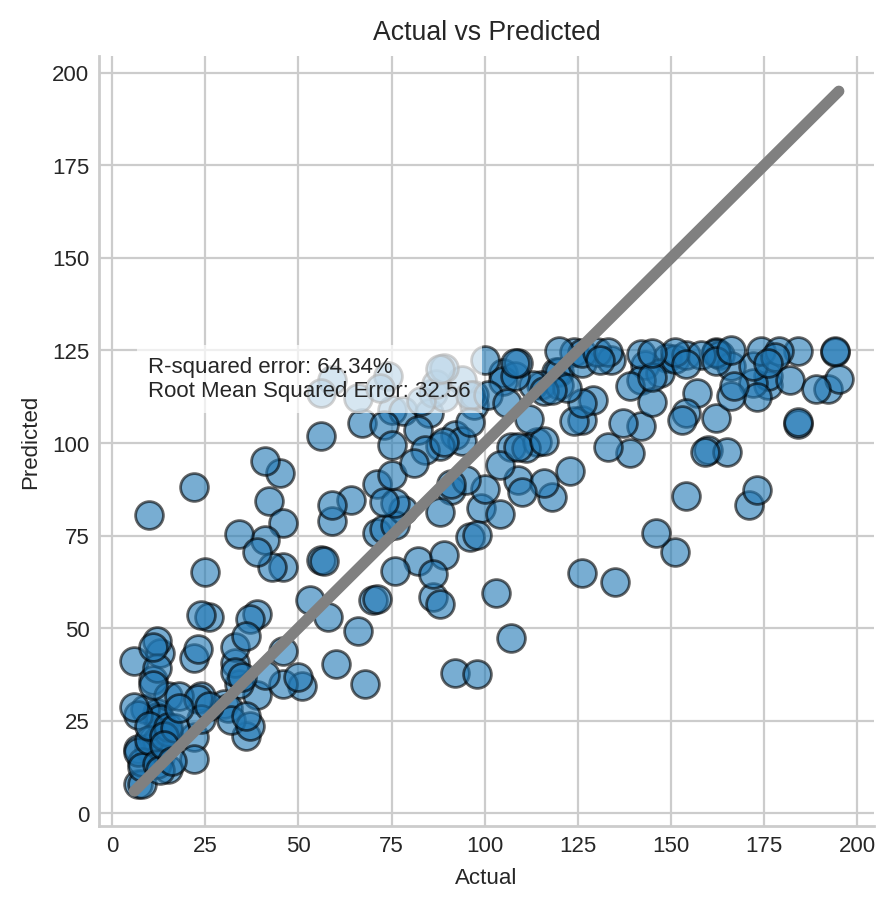

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=5,5

fig,ax = plt.subplots()
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=y_test,
                y=y_predictions,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(y_test),max(y_test)],
             y=[min(y_test),max(y_test)],
             linewidth=4,
             color='gray',
             ax=ax)

# Calculate RMSE by taking the square root of the mean squared error
rmse = mean_squared_error(y_test,y_predictions)**0.5

# Calculate R-squared using the trained model
r2 = model.score(X_test, y_test)

x_pos = 0.05 * max(y_test)
y_pos = 0.9 * max(y_predictions)

plt.annotate(
    text=(
        'R-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)) + '\n' +
        'Root Mean Squared Error: ' + "{:.2f}".format(rmse)
    ),
    xy=(x_pos, y_pos),
    size='medium',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # optional for readability
)

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

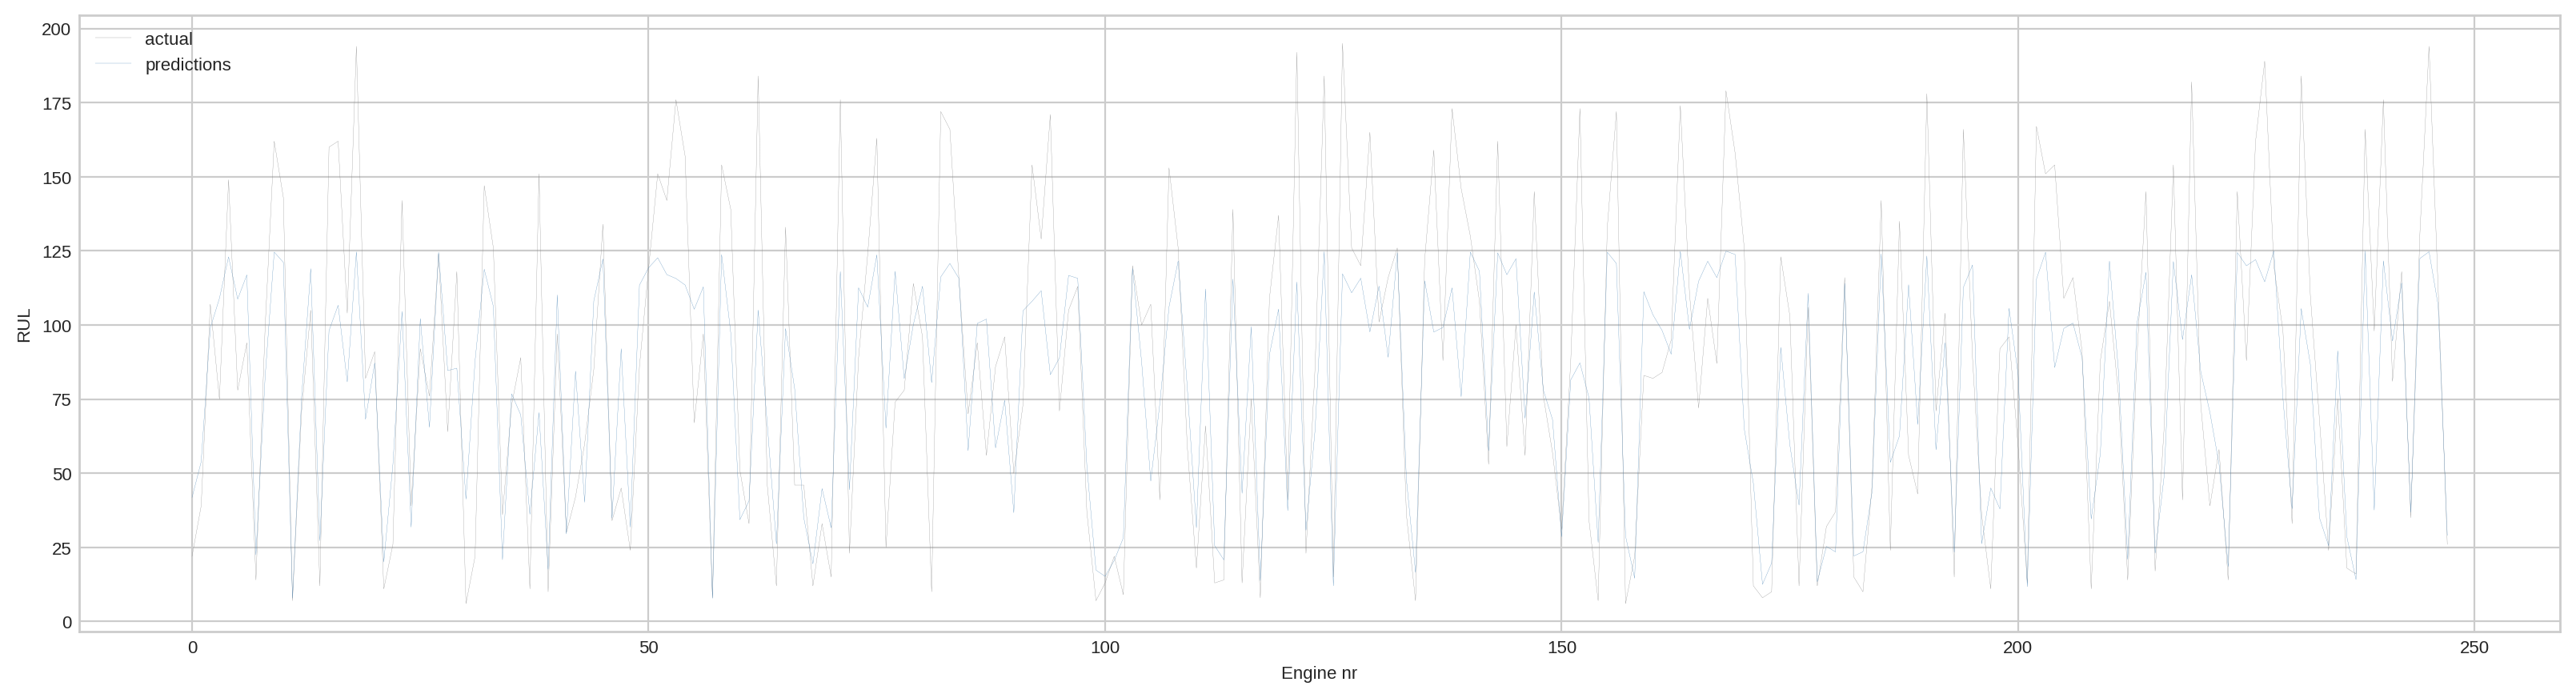

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=20,5

fig,ax = plt.subplots()
plt.ylabel('RUL')
plt.xlabel('Engine nr')

g = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_test.values.flatten(),
                color='gray',
                label = 'actual',
                ax=ax)

f = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_predictions,
                color='steelblue',
                label = 'predictions',
                ax=ax)
ax.legend()

# LSTM

In [ ]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import BatchNormalization, Dropout
# from tensorflow.keras.layers import preprocessing # Removed incorrect import
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping
import sklearn

In [ ]:
model = keras.Sequential()
model.add(LSTM(100,
                return_sequences=True,
               input_shape=(1,X_train.shape[1])
              ))
model.add(BatchNormalization())
model.add(LSTM(50,
                return_sequences=True,
               activation='tanh'
              ))
model.add(Dropout(0.5))
model.add(LSTM(10,
               return_sequences=True,
               activation='tanh',
              ))
model.add(Dropout(0.5))
model.add(Dense(100,
               activation='relu',
              ))
model.add(Dense(1))

In [ ]:
initial_learning_rate = 0.1
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True)

In [ ]:
model.compile(loss = "mse", optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 100)         │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 100)         │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 50)          │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 10)          │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 10)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1, 100)         │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1, 1)           │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,841 (304.07 KB)

 Trainable params: 77,641 (303.29 KB)

 Non-trainable params: 200 (800.00 B)

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=4, min_lr=1e-7, verbose=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_s, X_val, y_train_s, y_val = train_test_split(X_train, y_train, test_size=0.1)

#The LSTM input layer must be 3D.
#The meaning of the 3 input dimensions are: samples, time steps, and features.
#reshape input data
X_train_reshaped = X_train_s.reshape(X_train_s.shape[0], 1, X_train_s.shape[1])
X_val_reshaped = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test_reshaped = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [ ]:
%%time

start = time.time()
history = model.fit(x=X_train_reshaped,y=y_train_s,
                    validation_data = (X_val_reshaped,y_val),
                    epochs = 30,
                    # shuffle = True,
                    batch_size = 500,
                    callbacks=[reduce_lr]
                   )
end_train = time.time()
y_predictions = model.predict(X_test_reshaped) # These are the predictions from the test data.
end_predict = time.time()
y_predictions = y_predictions[:,0][:,0]
model_performance.loc['LSTM'] = [sklearn.metrics.r2_score(y_test, y_predictions),
                                   np.sqrt(mean_squared_error(y_test,y_predictions)),
                                   end_train-start,
                                   end_predict-end_train,
                                   end_predict-start]

print('R-squared error: '+ "{:.2%}".format(sklearn.metrics.r2_score(y_test, y_predictions)))
print('Root Mean Squared Error: '+ "{:.2f}".format(np.sqrt(mean_squared_error(y_test,y_predictions))))

Epoch 1/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 10041.9727 - val_loss: 7542.8818 - learning_rate: 0.0010
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 5841.1504 - val_loss: 2357.7737 - learning_rate: 0.0010
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 2395.8826 - val_loss: 5661.0083 - learning_rate: 0.0010
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1781.8761 - val_loss: 1900.3599 - learning_rate: 0.0010
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1619.8308 - val_loss: 1254.8599 - learning_rate: 0.0010
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 1513.8450 - val_loss: 1177.0352 - learning_rate: 0.0010
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1426.0588 - val_loss: 974.2751 - learning_rate: 0.0010
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1371.4106 - val_loss: 845.2523 - learning_rate: 0.0010
Epoch 9/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 130

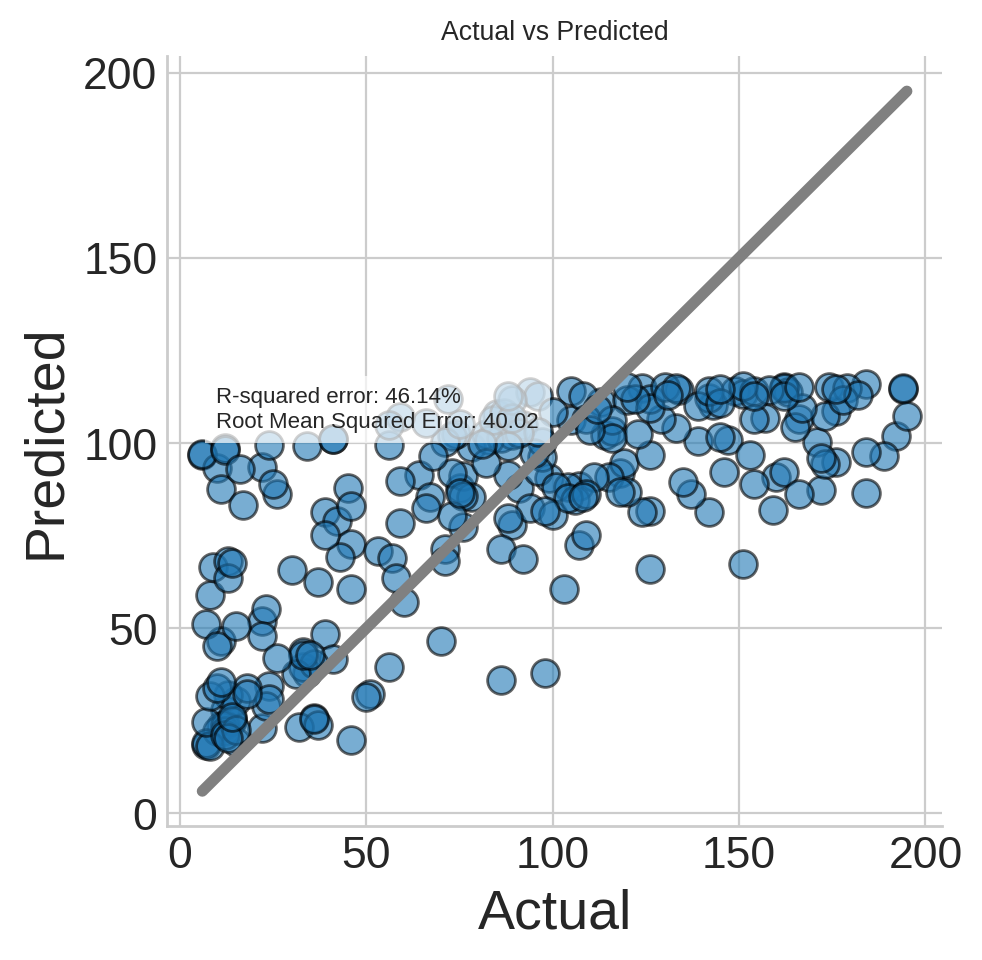

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=5,5
# Changed font.family to a font available in matplotlib to avoid warnings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=16
plt.rcParams['ytick.labelsize']=16
plt.rcParams['legend.fontsize']=16

fig,ax = plt.subplots()
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=y_test,
                y=y_predictions,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(y_test),max(y_test)],
             y=[min(y_test),max(y_test)],
             linewidth=4,
             color='gray',
             ax=ax)

# Calculate RMSE by taking the square root of the mean squared error
rmse = mean_squared_error(y_test,y_predictions)**0.5

# Calculate R-squared using sklearn.metrics.r2_score
r2 = sklearn.metrics.r2_score(y_test, y_predictions)

x_pos = 0.05 * max(y_test)
y_pos = 0.9 * max(y_predictions)

plt.annotate(
    text=(
        # Use the calculated R-squared
        'R-squared error: ' + "{:.2%}".format(r2) + '\n' +
        'Root Mean Squared Error: ' + "{:.2f}".format(rmse)
    ),
    xy=(x_pos, y_pos),
    size='medium',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # optional for readability
)

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

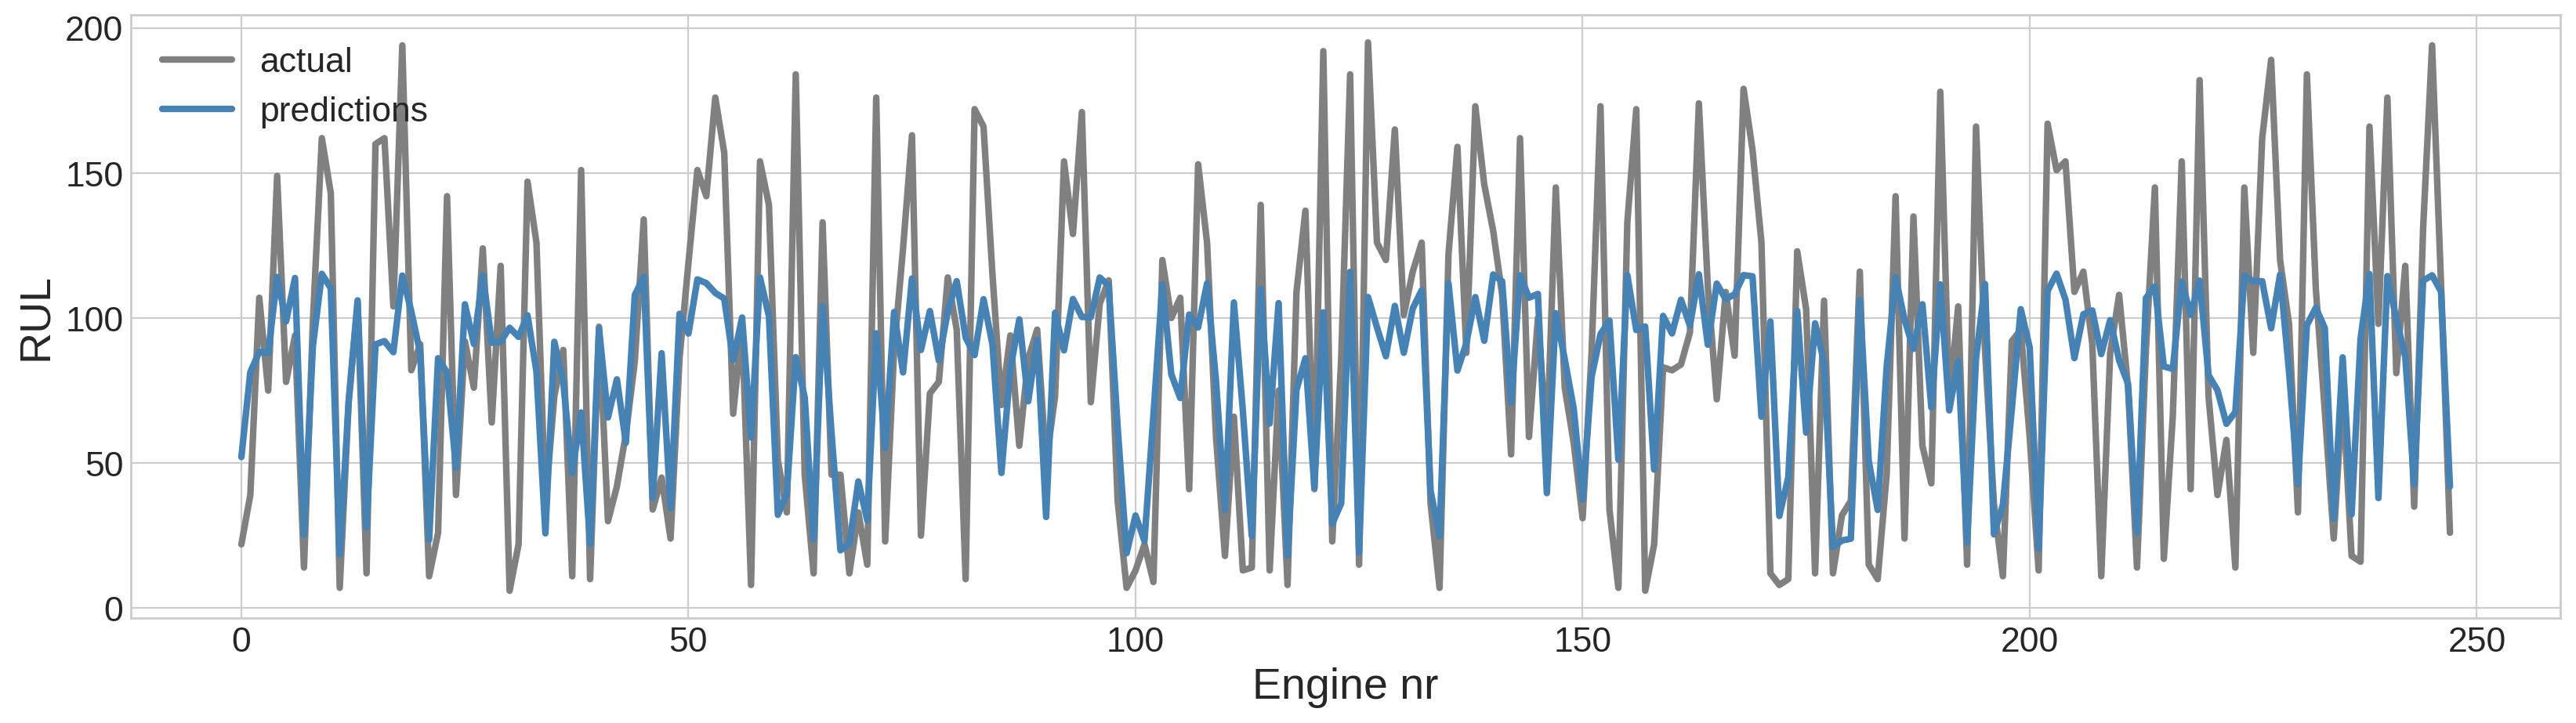

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=20,5

fig,ax = plt.subplots()
plt.ylabel('RUL')
plt.xlabel('Engine nr')

g = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_test.values.flatten(),
                color='gray',
                label = 'actual',
                ax=ax)

f = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_predictions,
                color='steelblue',
                label = 'predictions',
                ax=ax)
ax.legend()

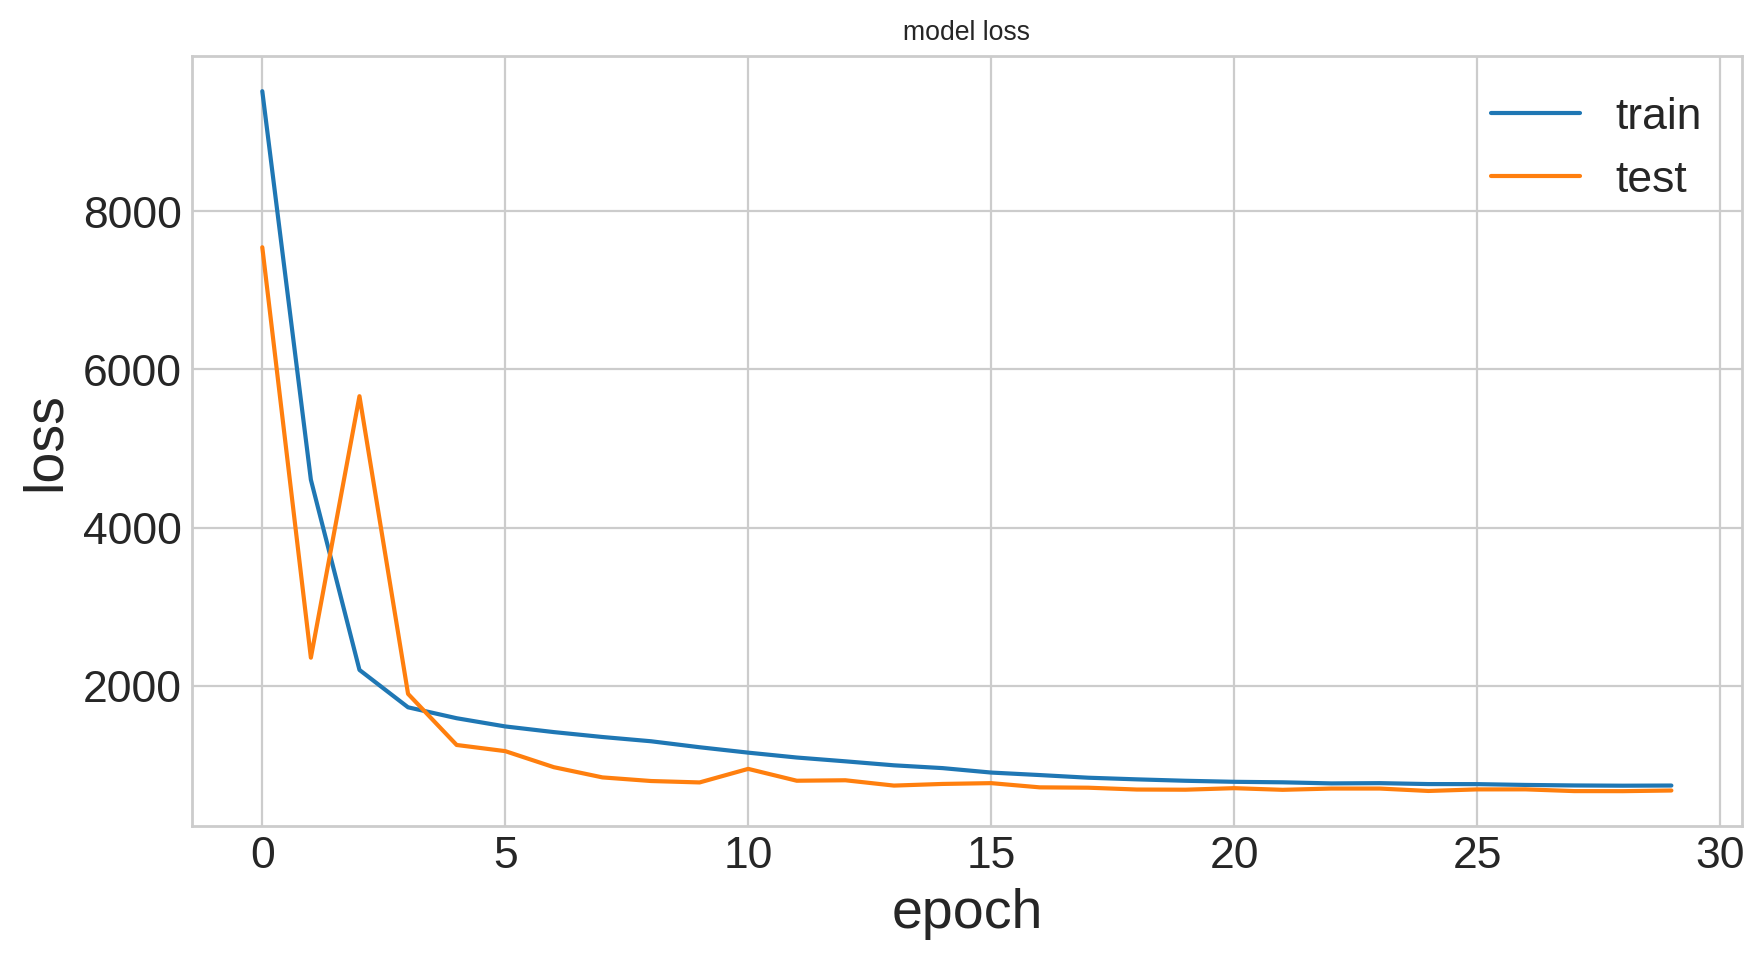

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=5,5
# Changed font.family to a font available in matplotlib to avoid warnings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 8
plt.rcParams['lines.linewidth'] = 1.5
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()

In [ ]:
model_performance.style.background_gradient(cmap='RdYlBu_r').format({'R2': '{:.2%}',
                                                                     'RMSE': '{:.2f}',
                                                                     'time to train':'{:.3f}',
                                                                     'time to predict':'{:.3f}',
                                                                     'total time':'{:.3f}',
                                                                     })

# AdaBoost

In [ ]:
%%time
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

start = time.time()

# Define parameter distributions for random search
param_distributions = {
    'n_estimators': randint(50, 500),                    # Number of boosting stages
    'learning_rate': uniform(0.01, 1.99),                # Learning rate (0.01 to 2.0)
    'loss': ['linear', 'square', 'exponential'],         # Loss function
    'estimator__max_depth': randint(1, 10),         # Max depth of base estimator
    'estimator__min_samples_split': randint(2, 20), # Min samples to split
    'estimator__min_samples_leaf': randint(1, 10)   # Min samples at leaf
}

# Create base model with decision tree estimator
base_estimator = DecisionTreeRegressor(random_state=42)
adaboost = AdaBoostRegressor(estimator=base_estimator, random_state=42)

# RandomizedSearchCV - faster than GridSearchCV
random_search = RandomizedSearchCV(
    adaboost,
    param_distributions=param_distributions,
    n_iter=20,              # Number of parameter settings sampled
    cv=3,                   # 3-fold cross-validation (fast)
    scoring='r2',           # Optimize for R-squared
    n_jobs=-1,              # Use all CPU cores
    random_state=42,
    verbose=1
)

# Fit the random search
random_search.fit(X_train, y_train)

# Best model
model = random_search.best_estimator_
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV score: {random_search.best_score_:.4f}")

end_train = time.time()

# Predictions
y_predictions = model.predict(X_test)
end_predict = time.time()

# Store performance
model_performance.loc['AdaBoost'] = [
    sklearn.metrics.r2_score(y_test, y_predictions),
    np.sqrt(mean_squared_error(y_test, y_predictions)),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('\nR-squared error: ' + "{:.2%}".format(sklearn.metrics.r2_score(y_test, y_predictions)))
print('Root Mean Squared Error: ' + "{:.2f}".format(np.sqrt(mean_squared_error(y_test, y_predictions))))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'estimator__max_depth': 9, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 11, 'learning_rate': np.float64(0.10286466979509469), 'loss': 'exponential', 'n_estimators': 239}
Best CV score: 0.6698

R-squared error: 54.20%
Root Mean Squared Error: 36.90
CPU times: user 1min 19s, sys: 1.45 s, total: 1min 21s
Wall time: 21min 13s


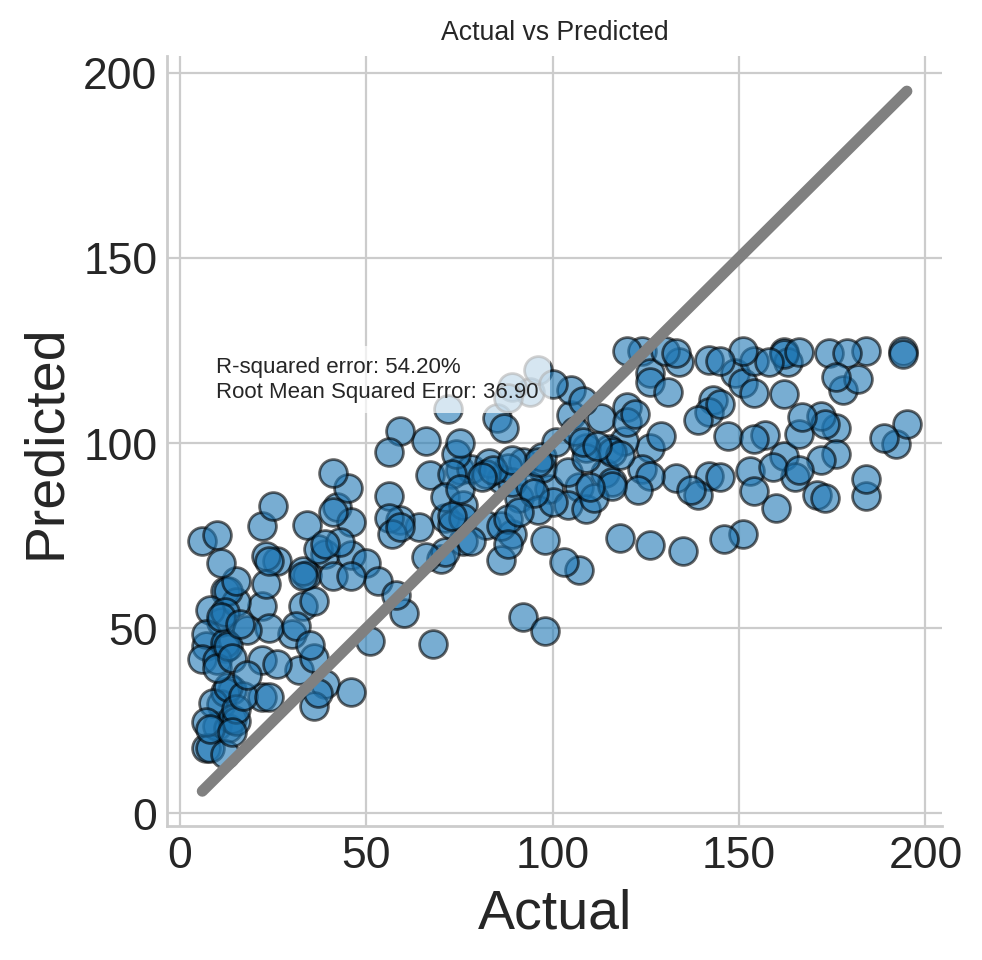

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=5,5

fig,ax = plt.subplots()
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=y_test,
                y=y_predictions,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(y_test),max(y_test)],
             y=[min(y_test),max(y_test)],
             linewidth=4,
             color='gray',
             ax=ax)

# Calculate RMSE by taking the square root of the mean squared error
rmse = mean_squared_error(y_test,y_predictions)**0.5

# Calculate R-squared using the trained model
r2 = model.score(X_test, y_test)

x_pos = 0.05 * max(y_test)
y_pos = 0.9 * max(y_predictions)

plt.annotate(
    text=(
        'R-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)) + '\n' +
        'Root Mean Squared Error: ' + "{:.2f}".format(rmse)
    ),
    xy=(x_pos, y_pos),
    size='medium',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # optional for readability
)

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

In [ ]:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize']=20,5

# fig,ax = plt.subplots()
# plt.ylabel('RUL')
# plt.xlabel('Engine nr')

# g = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
#                 y=y_test.values.flatten(),
#                 color='gray',
#                 label = 'actual',
#                 ax=ax)

# f = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
#                 y=y_predictions,
#                 color='steelblue',
#                 label = 'predictions',
#                 ax=ax)
# ax.legend()

# XGBoost

In [ ]:
%%time
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

start = time.time()

# Define parameter distributions for random search
param_distributions = {
    'n_estimators': randint(100, 1000),              # Number of boosting rounds
    'max_depth': randint(3, 10),                     # Maximum tree depth
    'learning_rate': uniform(0.01, 0.29),            # Learning rate (0.01 to 0.3)
    'subsample': uniform(0.6, 0.4),                  # Subsample ratio (0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4),           # Feature sampling (0.6 to 1.0)
    'min_child_weight': randint(1, 10),              # Minimum sum of instance weight
    'gamma': uniform(0, 0.5),                        # Minimum loss reduction
    'reg_alpha': uniform(0, 1),                      # L1 regularization
    'reg_lambda': uniform(0, 1)                      # L2 regularization
}

# Create base model
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'  # Faster training
)

# RandomizedSearchCV - faster than GridSearchCV
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_distributions,
    n_iter=25,              # Number of parameter settings sampled
    cv=3,                   # 3-fold cross-validation (fast)
    scoring='r2',           # Optimize for R-squared
    n_jobs=-1,              # Use all CPU cores
    random_state=42,
    verbose=1
)

# Fit the random search
random_search.fit(X_train, y_train)

# Best model
model = random_search.best_estimator_
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV score: {random_search.best_score_:.4f}")

end_train = time.time()

# Predictions
y_predictions = model.predict(X_test)
end_predict = time.time()

# Store performance
model_performance.loc['XGBoost'] = [
    model.score(X_test, y_test),
    np.sqrt(mean_squared_error(y_test, y_predictions)),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('\nR-squared error: ' + "{:.2%}".format(model.score(X_test, y_test)))
print('Root Mean Squared Error: ' + "{:.2f}".format(np.sqrt(mean_squared_error(y_test, y_predictions))))

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters: {'colsample_bytree': np.float64(0.8430179407605753), 'gamma': np.float64(0.08526206184364576), 'learning_rate': np.float64(0.02886496196573106), 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 415, 'reg_alpha': np.float64(0.5632882178455393), 'reg_lambda': np.float64(0.3854165025399161), 'subsample': np.float64(0.6063865008880857)}
Best CV score: 0.7515

R-squared error: 65.01%
Root Mean Squared Error: 32.25
CPU times: user 6.91 s, sys: 354 ms, total: 7.26 s
Wall time: 3min 53s


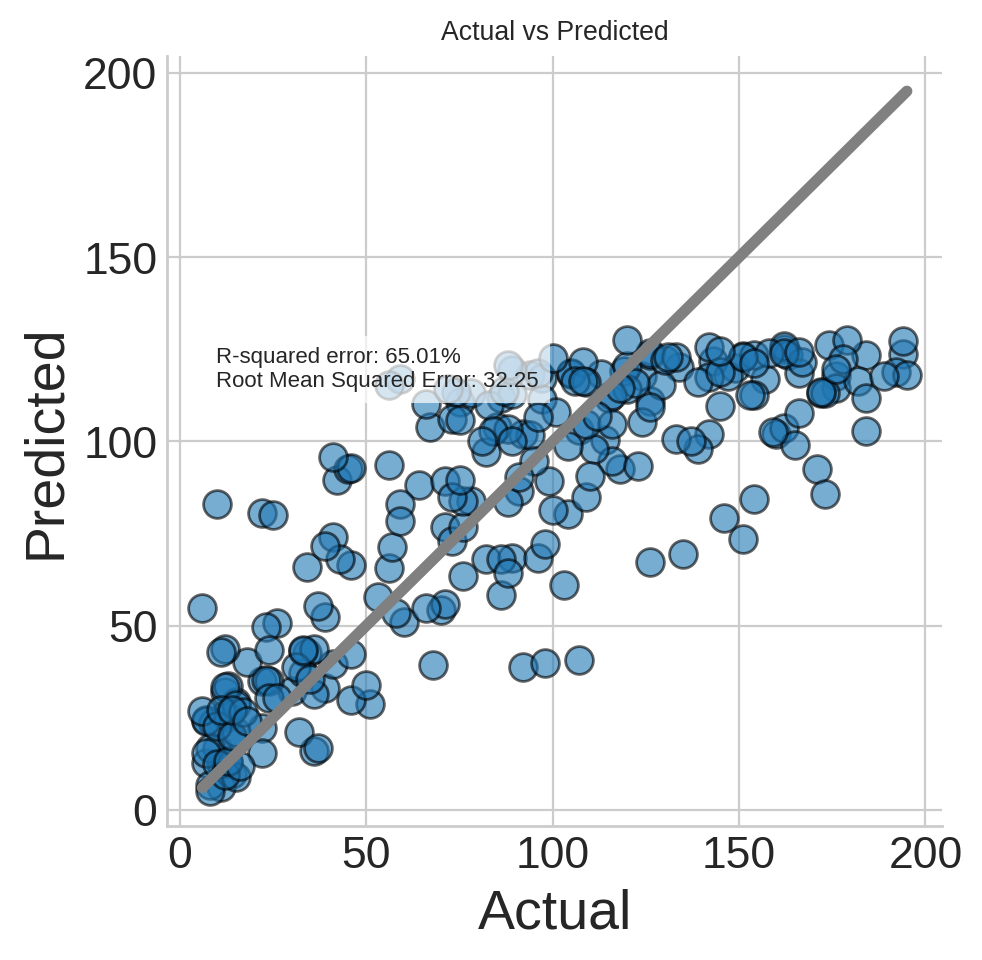

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=5,5
# Changed font.family to a font available in matplotlib to avoid warnings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=16
plt.rcParams['ytick.labelsize']=16
plt.rcParams['legend.fontsize']=16

fig,ax = plt.subplots()
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=y_test,
                y=y_predictions,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(y_test),max(y_test)],
             y=[min(y_test),max(y_test)],
             linewidth=4,
             color='gray',
             ax=ax)

# Calculate RMSE by taking the square root of the mean squared error
rmse = mean_squared_error(y_test,y_predictions)**0.5

# Calculate R-squared using sklearn.metrics.r2_score
r2 = sklearn.metrics.r2_score(y_test, y_predictions)

x_pos = 0.05 * max(y_test)
y_pos = 0.9 * max(y_predictions)

plt.annotate(
    text=(
        # Use the calculated R-squared
        'R-squared error: ' + "{:.2%}".format(r2) + '\n' +
        'Root Mean Squared Error: ' + "{:.2f}".format(rmse)
    ),
    xy=(x_pos, y_pos),
    size='medium',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # optional for readability
)

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

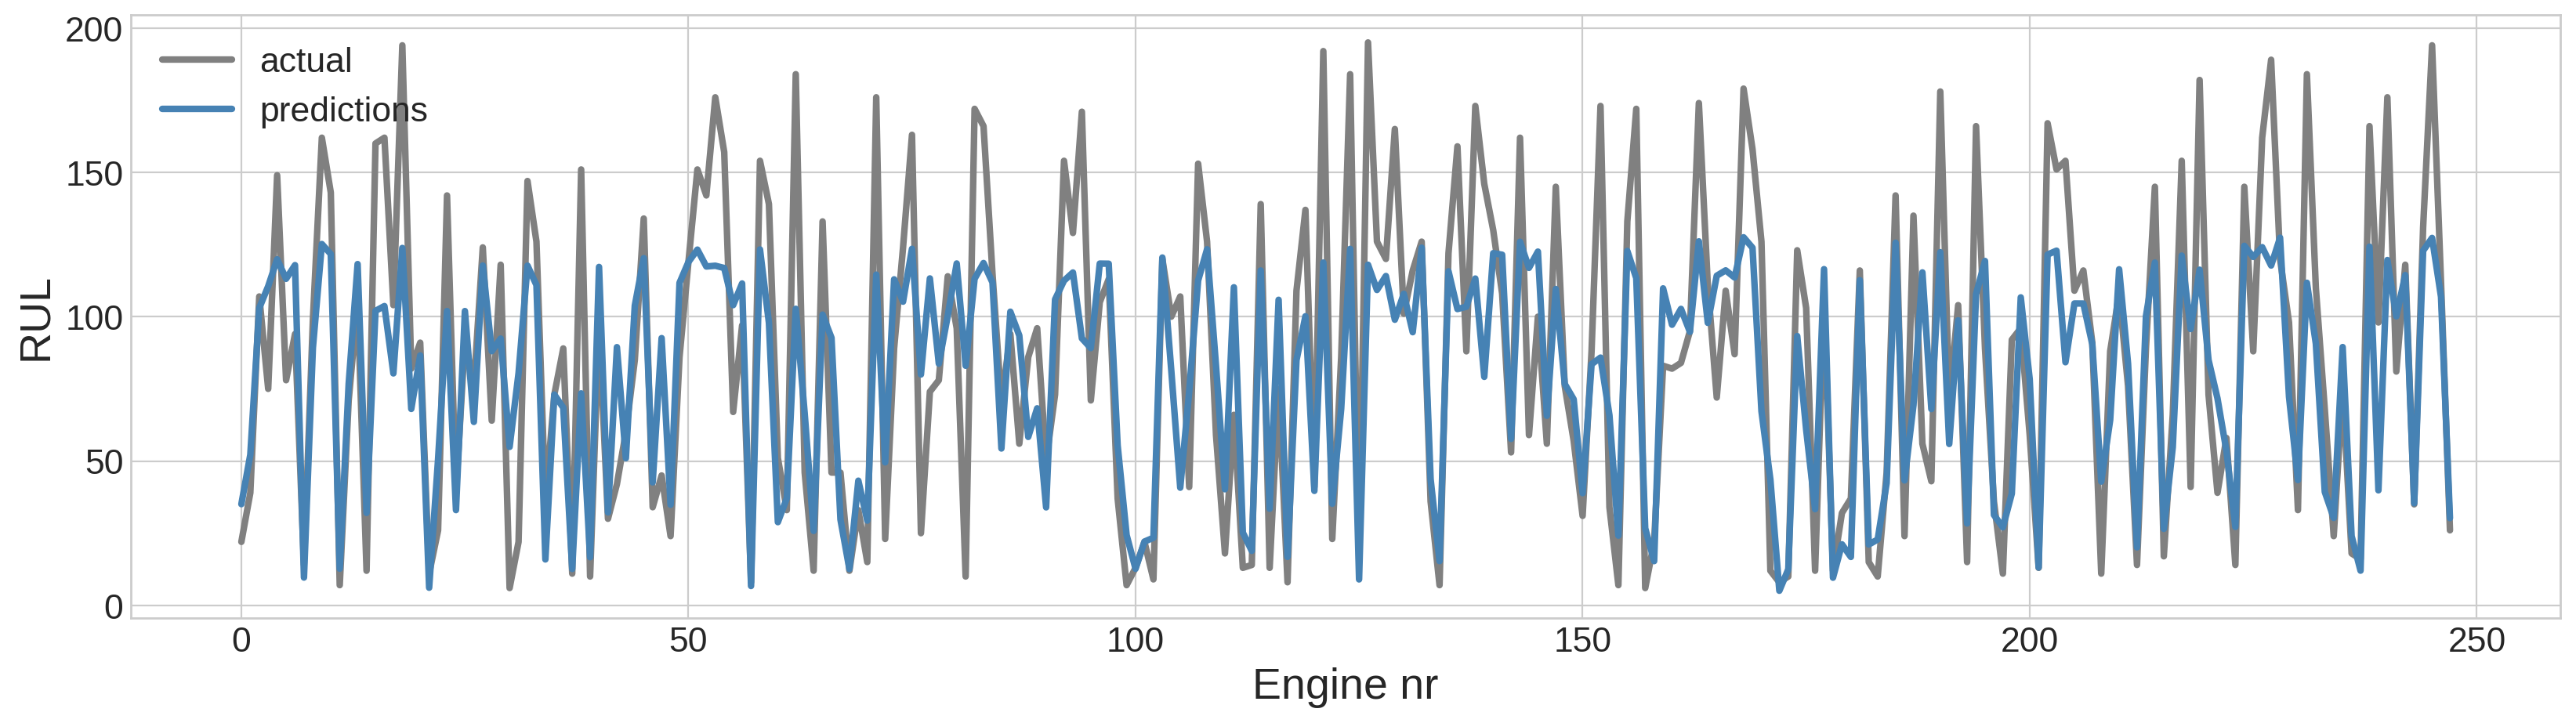

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']=20,5

fig,ax = plt.subplots()
plt.ylabel('RUL')
plt.xlabel('Engine nr')

g = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_test.values.flatten(),
                color='gray',
                label = 'actual',
                ax=ax)

f = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_predictions,
                color='steelblue',
                label = 'predictions',
                ax=ax)
ax.legend()